<a href="https://colab.research.google.com/github/aartinangare1745/Machine-Learning/blob/main/gradientdescent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

Learning Rate in Gradient Descent

The **learning rate** is a hyperparameter in optimization algorithms like gradient descent that determines the step size at each iteration while moving toward a minimum of a loss function. It's a crucial factor in how quickly and effectively a model converges.

*   **If the learning rate is too small:** The convergence will be very slow, requiring many iterations to reach the optimal solution. The algorithm might get stuck in local minima or take a very long time to escape shallow areas.

*   **If the learning rate is too large (like in your current case):** The algorithm might overshoot the minimum of the loss function. Instead of converging, the `param` (weight) will jump back and forth, or even move further away from the minimum in each step. This leads to the `loss` increasing significantly over iterations, a phenomenon known as **divergence**.



In [10]:

X = np.array([1, 2, 3, 4, 5])
y = np.array([6, 7, 8, 9, 10])


def run_gradient_descent(X, y, learning_rate, n_iterations):
    param = 0
    loss_history = []
    for i in range(n_iterations):
        y_pred = param * X
        loss = np.mean((y - y_pred)**2)
        loss_history.append(loss)
        gradient = -2 * np.mean(X * (y - y_pred))
        param = param - learning_rate * gradient
    return param, loss_history


n_iterations = 100

# Case 1: High Learning Rate (0.1) - Divergence
param_high_lr, loss_history_high_lr = run_gradient_descent(X, y, 0.1, n_iterations)
print(f"\n--- High Learning Rate (0.1) ---")
print(f"Final weight: {param_high_lr}")
print(f"Final loss: {loss_history_high_lr[-1]}")

# Case 2: Moderate Learning Rate (0.01) - Convergence
param_moderate_lr, loss_history_moderate_lr = run_gradient_descent(X, y, 0.01, n_iterations)
print(f"\n--- Moderate Learning Rate (0.01) ---")
print(f"Final weight: {param_moderate_lr}")
print(f"Final loss: {loss_history_moderate_lr[-1]}")

# Case 3: Very Small Learning Rate (0.0001) - Slow Convergence
param_small_lr, loss_history_small_lr = run_gradient_descent(X, y, 0.0001, n_iterations)
print(f"\n--- Small Learning Rate (0.0001) ---")
print(f"Final weight: {param_small_lr}")
print(f"Final loss: {loss_history_small_lr[-1]}")


--- High Learning Rate (0.1) ---
Final weight: -195751573.77930912
Final loss: 2.9271213554647315e+17

--- Moderate Learning Rate (0.01) ---
Final weight: 2.363636363598078
Final loss: 4.545454545454545

--- Small Learning Rate (0.0001) ---
Final weight: 0.4672334096927986
Final loss: 44.2798795016296


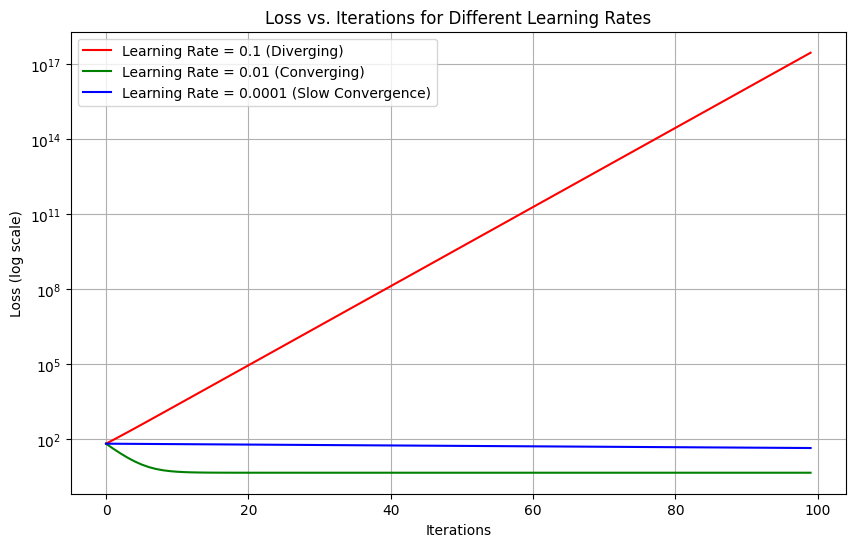

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(loss_history_high_lr, label='Learning Rate = 0.1 (Diverging)', color='red')
plt.plot(loss_history_moderate_lr, label='Learning Rate = 0.01 (Converging)', color='green')
plt.plot(loss_history_small_lr, label='Learning Rate = 0.0001 (Slow Convergence)', color='blue')
plt.yscale('log') #log scale for y-axis
plt.title('Loss vs. Iterations for Different Learning Rates')
plt.xlabel('Iterations')
plt.ylabel('Loss (log scale)')
plt.legend()
plt.grid(True)
plt.show()



*   With a **high learning rate (0.1)**, the loss quickly escalates, demonstrating **divergence**.
*   With a **moderate learning rate (0.01)**, the loss decreases and converges to a stable, low value.
*   With a **very small learning rate (0.0001)**, the loss decreases very slowly, indicating **slow convergence**.

This experiment visually confirms that your initial learning rate of 0.1 was indeed too high, causing the algorithm to diverge.